# Siamese CNN Training for Fragmented ID Resolution

This notebook trains an end-to-end Siamese network that:
1. Takes raw text pairs as input
2. Embeds both with a shared CharCNN encoder
3. Classifies whether they're duplicates

In [61]:
# Imports and Setup
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import custom modules
sys.path.append('src')
from model import CharCNNEncoder
from model_utils import char_to_idx, vocab_size
from pair_text_dataset import PairTextDataset
from siamese_cnn import SiameseCNN
from siamese_train_utils import train_epoch, evaluate, print_evaluation_report

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Vocab size: {vocab_size}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
Vocab size: 38


In [62]:

# ============================================================================
# UTILITY FUNCTIONS FOR DATA LOADING, TRAINING, AND EVALUATION
# ============================================================================

def load_and_create_datasets(train_path, val_path, test_path, features, max_len=100, batch_size=128):
    """Load CSV files and create datasets with DataLoaders"""
    print("\n" + "="*60)
    print(f"LOADING DATA: {train_path}, {val_path}, {test_path}")
    print("="*60)
    
    # Load data
    train_data = pd.read_csv(train_path)
    val_data = pd.read_csv(val_path)
    test_data = pd.read_csv(test_path)
    
    # Create datasets
    train_dataset = PairTextDataset(data=train_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    val_dataset = PairTextDataset(data=val_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    test_dataset = PairTextDataset(data=test_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nDataLoaders created:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    
    return train_loader, val_loader, test_loader


def train_and_evaluate_model(train_loader, val_loader, model_name, epochs=30, learning_rate=0.001):
    """Initialize, train, and evaluate a Siamese CNN model"""
    print("\n" + "="*60)
    print(f"TRAINING MODEL: {model_name}")
    print("="*60)
    
    # Hyperparameters
    EMBED_DIM = 32
    NUM_FILTERS = 128
    KERNEL_SIZES = (3, 4, 5)
    DROPOUT = 0.3
    CNN_OUTPUT_DIM = 128
    
    # Initialize model
    model = SiameseCNN(
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        num_filters=NUM_FILTERS,
        kernel_sizes=KERNEL_SIZES,
        dropout=DROPOUT,
        cnn_output_dim=CNN_OUTPUT_DIM
    ).to(device)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)
    
    # Training history
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 
               'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0.0
    best_epoch = 0
    
    os.makedirs('models', exist_ok=True)
    
    # Training loop
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning Rate: {current_lr:.6f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            model_path = f'models/best_{model_name}.pth'
            torch.save(model.state_dict(), model_path)
            print(f"🎯 NEW BEST F1: {best_val_f1:.4f}")
    
    print(f"\nBest Validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")
    
    return model, history, best_val_f1, best_epoch


def plot_and_save_history(history, model_name, title):
    """Plot and save training history"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss - {title}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy - {title}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    best_f1 = max(history['val_f1'])
    axes[2].plot(history['train_f1'], label='Train F1', marker='o', linewidth=2)
    axes[2].plot(history['val_f1'], label='Val F1', marker='s', linewidth=2)
    axes[2].axhline(y=best_f1, color='r', linestyle='--', linewidth=2, label=f'Best F1: {best_f1:.4f}')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title(f'F1 Score - {title}', fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = f'training_history_{model_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Training history plot saved as '{plot_path}'")
    
    # Save history as CSV
    history_df = pd.DataFrame(history)
    csv_path = f'training_history_{model_name}.csv'
    history_df.to_csv(csv_path, index=False)
    print(f"Training history CSV saved as '{csv_path}'")


def evaluate_on_test(model, test_loader, model_name, criterion, device):
    """Evaluate model on test set and save results"""
    print("\n" + "="*60)
    print(f"EVALUATING {model_name.upper()} ON TEST SET")
    print("="*60)
    
    model.eval()
    test_loss, test_acc, test_f1, test_labels, test_preds, test_probs = evaluate(
        model, test_loader, criterion, device
    )
    cm, precision, recall, specificity, final_f1 = print_evaluation_report(
        test_labels, test_preds, test_probs
    )
    
    # Save results
    tn, fp, fn, tp = cm.ravel()
    with open(f'test_results_{model_name}.txt', 'w') as f:
        f.write("="*60 + "\n")
        f.write(f"TEST RESULTS - {model_name.upper()}\n")
        f.write("="*60 + "\n\n")
        f.write("Test Metrics:\n")
        f.write(f"  Loss: {test_loss:.4f}\n")
        f.write(f"  Accuracy: {test_acc:.4f}\n")
        f.write(f"  F1 Score: {final_f1:.4f}\n")
        f.write(f"  Precision: {precision:.4f}\n")
        f.write(f"  Recall: {recall:.4f}\n")
        f.write(f"  Specificity: {specificity:.4f}\n\n")
        f.write("Confusion Matrix:\n")
        f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
        f.write(f"  FN={fn:6d}  TP={tp:6d}\n")
    
    print(f"Test results saved to 'test_results_{model_name}.txt'")
    
    return test_loss, test_acc, final_f1, precision, recall, specificity


def load_model_and_validate(model_name, val_loader, criterion, device):
    """Load model and evaluate on validation set"""
    print("\n" + "="*60)
    print(f"VALIDATING {model_name.upper()}")
    print("="*60)
    
    model = SiameseCNN(
        vocab_size=vocab_size,
        embed_dim=32,
        num_filters=128,
        kernel_sizes=(3, 4, 5),
        dropout=0.3,
        cnn_output_dim=128
    ).to(device)
    
    model_path = f'models/best_{model_name}.pth'
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate(
        model, val_loader, criterion, device
    )
    
    cm, precision, recall, specificity, final_f1 = print_evaluation_report(
        val_labels, val_preds, val_probs
    )
    
    print(f"\nValidation Results:")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  F1 Score: {final_f1:.4f}")
    
    return model, cm, precision, recall, specificity, final_f1


In [63]:
train_aug_data = pd.read_csv('data/train_pairs_aug.csv')
val_aug_data = pd.read_csv('data/val_pairs_aug.csv')
test_aug_data = pd.read_csv('data/test_pairs_aug.csv')
val_noaug_data = pd.read_csv('data/val_pairs.csv')
test_noaug_data = pd.read_csv('data/test_pairs.csv')

C:\Users\arpit\AppData\Local\Temp\ipykernel_17836\1818582478.py:1: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  train_aug_data = pd.read_csv('data/train_pairs_aug.csv')


Use PairTextDataset to seperate ID1 and ID2 info, tokenize and load data in batches

In [64]:
# Define features and hyperparameters
FEATURES = ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']
MAX_LEN = 100
BATCH_SIZE = 128
EPOCHS = 30

# Load augmented data and create DataLoaders
train_loader, val_loader, test_loader = load_and_create_datasets(
    'data/train_pairs_aug.csv',
    'data/val_pairs_aug.csv',
    'data/test_pairs_aug.csv',
    features=FEATURES,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE
)


LOADING DATA: data/train_pairs_aug.csv, data/val_pairs_aug.csv, data/test_pairs_aug.csv


C:\Users\arpit\AppData\Local\Temp\ipykernel_17836\1461057602.py:12: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(train_path)



Loaded 65503 pairs from the data
  - Duplicates: 13652
  - Non-duplicates: 51851
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 6901 pairs from the data
  - Duplicates: 2938
  - Non-duplicates: 3963
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 7475 pairs from the data
  - Duplicates: 3048
  - Non-duplicates: 4427
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

DataLoaders created:
  Train batches: 512
  Val batches: 54
  Test batches: 59


## Training with Hard Negative Weighting

Apply higher loss weight to confusing non-duplicate pairs (same name + different age, same address + different person, etc.) to force the model to learn better discrimination.


In [65]:
# Step 1: Compute hard negative weights
from hard_negative_weights import compute_hard_negative_weights

# Compute weights with configurable hyperparameters
hard_negative_weights_aug, is_hard_negative_aug = compute_hard_negative_weights(
    data=train_aug_data,
    hard_negative_weight=2.0,      # HYPERPARAMETER: 1.5, 2.0, 2.5, 3.0
    similarity_threshold=0.7,      # HYPERPARAMETER: 0.6, 0.7, 0.8
    return_mask=True
)

print(f"\nHard Negative Weights computed:")
print(f"  Shape: {hard_negative_weights_aug.shape}")
print(f"  Dtype: {hard_negative_weights_aug.dtype}")
print(f"  Unique values: {np.unique(hard_negative_weights_aug)}")



COMPUTING HARD NEGATIVE WEIGHTS
Hard negative weight: 2.0x
Similarity threshold: 0.7
  Computing name similarities (n=51851 non-duplicates)...

  Hard Negative Buckets:
    same_first_last_diff_age: 1
    same_first_and_age_diff_last: 17

SUMMARY
Total samples: 65,503
  Duplicates (label=1): 13,652 (20.8%)
  Non-duplicates (label=0): 51,851 (79.2%)
  Hard negatives: 18 (0.0%)

Weight distribution:
  Regular samples: 65,485 with weight 1.0x
  Hard negatives: 18 with weight 2.0x


Hard Negative Weights computed:
  Shape: (65503,)
  Dtype: float32
  Unique values: [1. 2.]


In [66]:
# Step 2: Train model with hard negative weights using the wrapper function
from src.siamese_train_utils import train_with_hard_negatives

print("\n" + "="*70)
print("TRAINING WITH HARD NEGATIVE WEIGHTS (Augmented Data)")
print("="*70)

# Create optimizers for hard negative training
optimizer_hn = optim.Adam(model.parameters(), lr=0.001)
scheduler_hn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hn, 'max', patience=3, factor=0.5)

# Initialize fresh model for hard negative training
model_hn = SiameseCNN(
    vocab_size=vocab_size,
    embed_dim=32,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    cnn_output_dim=128
).to(device)

optimizer_hn = optim.Adam(model_hn.parameters(), lr=0.001)
scheduler_hn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hn, 'max', patience=3, factor=0.5)

# Train with hard negative weighting
model_hn, history_hn, best_val_f1_hn, best_epoch_hn = train_with_hard_negatives(
    model=model_hn,
    train_loader=train_loader,
    val_loader=val_loader,
    train_df=train_aug_data,
    criterion=criterion,
    optimizer=optimizer_hn,
    scheduler=scheduler_hn,
    device=device,
    epochs=EPOCHS,
    hard_negative_weight=2.0,      # HYPERPARAMETER to tune
    similarity_threshold=0.7       # HYPERPARAMETER to tune
)



TRAINING WITH HARD NEGATIVE WEIGHTS (Augmented Data)

TRAINING WITH HARD NEGATIVE WEIGHTING

COMPUTING HARD NEGATIVE WEIGHTS
Hard negative weight: 2.0x
Similarity threshold: 0.7
  Computing name similarities (n=51851 non-duplicates)...

  Hard Negative Buckets:
    same_first_last_diff_age: 1
    same_first_and_age_diff_last: 17

SUMMARY
Total samples: 65,503
  Duplicates (label=1): 13,652 (20.8%)
  Non-duplicates (label=0): 51,851 (79.2%)
  Hard negatives: 18 (0.0%)

Weight distribution:
  Regular samples: 65,485 with weight 1.0x
  Hard negatives: 18 with weight 2.0x


Epoch 1/30


Train - Loss: 0.4532, Acc: 0.7868, F1: 0.0140
Val   - Loss: 0.5053, Acc: 0.5743, F1: 0.0000
Learning Rate: 0.001000

Epoch 2/30


Train - Loss: 0.2716, Acc: 0.8659, F1: 0.6389
Val   - Loss: 0.2181, Acc: 0.9081, F1: 0.9019
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9019

Epoch 3/30


Train - Loss: 0.1100, Acc: 0.9566, F1: 0.8965
Val   - Loss: 0.0987, Acc: 0.9639, F1: 0.9592
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9592

Epoch 4/30


Train - Loss: 0.0546, Acc: 0.9803, F1: 0.9530
Val   - Loss: 0.0726, Acc: 0.9739, F1: 0.9703
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9703

Epoch 5/30


...

Train - Loss: 0.0093, Acc: 0.9968, F1: 0.9922
Val   - Loss: 0.0257, Acc: 0.9936, F1: 0.9925
Learning Rate: 0.001000

Epoch 27/30


Train - Loss: 0.0083, Acc: 0.9973, F1: 0.9935
Val   - Loss: 0.0258, Acc: 0.9928, F1: 0.9915
Learning Rate: 0.000500

Epoch 28/30


Train - Loss: 0.0055, Acc: 0.9980, F1: 0.9953
Val   - Loss: 0.0254, Acc: 0.9945, F1: 0.9936
Learning Rate: 0.000500

Epoch 29/30


Train - Loss: 0.0053, Acc: 0.9983, F1: 0.9959
Val   - Loss: 0.0196, Acc: 0.9942, F1: 0.9932
Learning Rate: 0.000500

Epoch 30/30


Train - Loss: 0.0050, Acc: 0.9983, F1: 0.9960
Val   - Loss: 0.0192, Acc: 0.9942, F1: 0.9932
Learning Rate: 0.000500

Training complete! Best Validation F1: 0.9941 (Epoch 23)



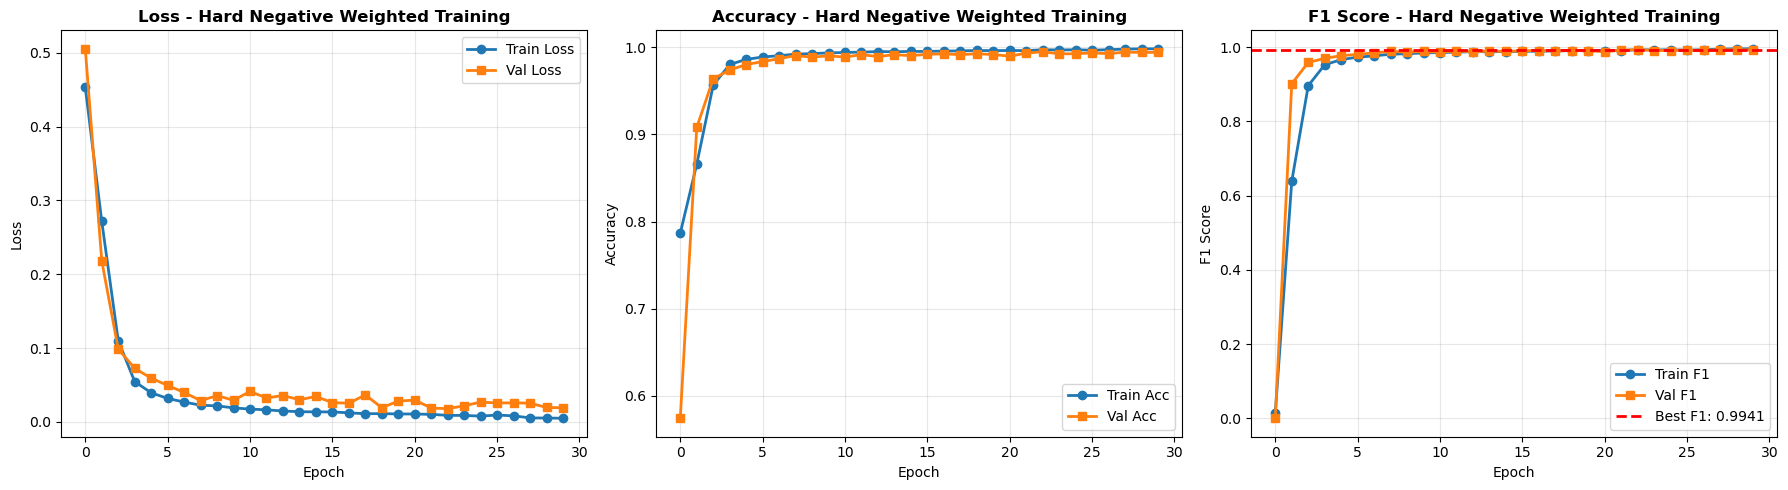

Training history plot saved as 'training_history_siamese_cnn_hard_negatives.png'
Training history CSV saved as 'training_history_siamese_cnn_hard_negatives.csv'

Hard negative model saved to: models\best_siamese_cnn_hard_negatives.pth
Model parameters: 273,601


In [69]:
# Step 3: Plot and save training history and model for hard negative model
plot_and_save_history(history_hn, 'siamese_cnn_hard_negatives', 'Hard Negative Weighted Training')

# Save the trained hard negative model
model_path = os.path.join('models', 'best_siamese_cnn_hard_negatives.pth')
torch.save(model_hn.state_dict(), model_path)
print(f"\nHard negative model saved to: {model_path}")
print(f"Model parameters: {sum(p.numel() for p in model_hn.parameters()):,}")


In [71]:
# Step 4: Load and validate hard negative model
model_hn, cm_hn, precision_hn, recall_hn, specificity_hn, final_f1_hn = load_model_and_validate(
    'siamese_cnn_hard_negatives', val_loader, criterion, device
)



VALIDATING SIAMESE_CNN_HARD_NEGATIVES



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9985    0.9914    0.9949      3963
    Duplicate     0.9885    0.9980    0.9932      2938

     accuracy                         0.9942      6901
    macro avg     0.9935    0.9947    0.9941      6901
 weighted avg     0.9942    0.9942    0.9942      6901


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     3929     34
        Pos        6   2932

Additional Metrics:
  Precision: 0.9885
  Recall (Sensitivity): 0.9980
  Specificity: 0.9914
  F1 Score: 0.9932

Validation Results:
  Loss: 0.0192
  Accuracy: 0.9942
  F1 Score: 0.9932


## Testing 

This section evaluates the hard negative weighted model on multiple test configurations:

1. **Augmented Test Set (Whole)**: Tests on entire augmented test dataset
2. **Augmented Test Set (Hard Positives)**: Tests on duplicates with different last names + all negatives
3. **Non-Augmented Test Set (Whole)**: Tests on entire non-augmented test dataset  
4. **Non-Augmented Test Set (Hard Positives)**: Tests on hard positives subset + all negatives


In [78]:
### Test 1: Augmented Test Set (Whole Set)

print("\n" + "="*80)
print("TEST 1: AUGMENTED TEST SET - WHOLE SET")
print("="*80)

# Evaluate on whole augmented test set
test_loss_aug_whole, test_acc_aug_whole, _, test_labels_aug_whole, test_preds_aug_whole, test_probs_aug_whole = evaluate(
    model_hn, test_loader, criterion, device
)
cm_aug_whole, prec_aug_whole, rec_aug_whole, spec_aug_whole, f1_aug_whole = print_evaluation_report(
    test_labels_aug_whole, test_preds_aug_whole, test_probs_aug_whole
)

print(f"\nAugmented Test Set (Whole) Results:")
print(f"  Samples: {len(test_aug_data)}")
print(f"  Loss: {test_loss_aug_whole:.4f}")
print(f"  Precision: {prec_aug_whole:.4f}")
print(f"  Recall: {rec_aug_whole:.4f}")
print(f"  Specificity: {spec_aug_whole:.4f}")
print(f"  F1 Score: {f1_aug_whole:.4f}")



TEST 1: AUGMENTED TEST SET - WHOLE SET



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9982    0.9921    0.9951      4427
    Duplicate     0.9886    0.9974    0.9930      3048

     accuracy                         0.9942      7475
    macro avg     0.9934    0.9947    0.9941      7475
 weighted avg     0.9943    0.9942    0.9943      7475


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4392     35
        Pos        8   3040

Additional Metrics:
  Precision: 0.9886
  Recall (Sensitivity): 0.9974
  Specificity: 0.9921
  F1 Score: 0.9930

Augmented Test Set (Whole) Results:
  Samples: 7475
  Loss: 0.0273
  Precision: 0.9886
  Recall: 0.9974
  Specificity: 0.9921
  F1 Score: 0.9930


In [79]:
### Test 2: Augmented Test Set (Hard Positives - Different Last Names + All Negatives)

print("\n" + "="*80)
print("TEST 2: AUGMENTED TEST SET - HARD POSITIVES (DLN + NEGATIVES)")
print("="*80)

# Filter for hard positives (duplicates with different last names) + all negatives
filtered_aug_test = test_aug_data[
    ((test_aug_data['label'] == 1) & (test_aug_data['last_name_1'] != test_aug_data['last_name_2'])) | 
    (test_aug_data['label'] == 0)
]

# Create filtered dataloader
filtered_test_dataset_aug = PairTextDataset(
    data=filtered_aug_test, 
    char_to_idx=char_to_idx, 
    max_len=MAX_LEN, 
    features=FEATURES
)
filtered_test_loader_aug = DataLoader(
    filtered_test_dataset_aug, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0
)

# Evaluate on filtered augmented test set
test_loss_aug_hp, test_acc_aug_hp, _, test_labels_aug_hp, test_preds_aug_hp, test_probs_aug_hp = evaluate(
    model_hn, filtered_test_loader_aug, criterion, device
)
cm_aug_hp, prec_aug_hp, rec_aug_hp, spec_aug_hp, f1_aug_hp = print_evaluation_report(
    test_labels_aug_hp, test_preds_aug_hp, test_probs_aug_hp
)

print(f"\nAugmented Test Set (Hard Positives) Results:")
print(f"  Samples: {len(filtered_aug_test)} (filtered from {len(test_aug_data)})")
print(f"  Duplicates (DLN): {(filtered_aug_test['label'] == 1).sum()}")
print(f"  Non-Duplicates: {(filtered_aug_test['label'] == 0).sum()}")
print(f"  Loss: {test_loss_aug_hp:.4f}")
print(f"  Precision: {prec_aug_hp:.4f}")
print(f"  Recall: {rec_aug_hp:.4f}")
print(f"  Specificity: {spec_aug_hp:.4f}")
print(f"  F1 Score: {f1_aug_hp:.4f}")



TEST 2: AUGMENTED TEST SET - HARD POSITIVES (DLN + NEGATIVES)

Loaded 4869 pairs from the data
  - Duplicates: 442
  - Non-duplicates: 4427
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9991    0.9921    0.9956      4427
    Duplicate     0.9260    0.9910    0.9574       442

     accuracy                         0.9920      4869
    macro avg     0.9625    0.9915    0.9765      4869
 weighted avg     0.9925    0.9920    0.9921      4869


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4392     35
        Pos        4    438

Additional Metrics:
  Precision: 0.9260
  Recall (Sensitivity): 0.9910
  Specificity: 0.9921
  F1 Score: 0.9574

Augmented Test Set (Hard Positives) Results:
  Samples: 4869 (filtered from 7475)
  Duplicates (DLN): 442
  Non-Duplicates: 4427
  Loss: 0.0363
  Precision: 0.9260
  Recall: 0.9910
  Specificity: 0.9921
  F1 Score: 0.9574


In [80]:
### Test 3: Non-Augmented Test Set (Whole Set)

print("\n" + "="*80)
print("TEST 3: NON-AUGMENTED TEST SET - WHOLE SET")
print("="*80)

# Evaluate on whole non-augmented test set
test_loss_noaug_whole, test_acc_noaug_whole, _, test_labels_noaug_whole, test_preds_noaug_whole, test_probs_noaug_whole = evaluate(
    model_hn, test_loader_noaug, criterion, device
)
cm_noaug_whole, prec_noaug_whole, rec_noaug_whole, spec_noaug_whole, f1_noaug_whole = print_evaluation_report(
    test_labels_noaug_whole, test_preds_noaug_whole, test_probs_noaug_whole
)

print(f"\nNon-Augmented Test Set (Whole) Results:")
print(f"  Samples: {len(test_noaug_data)}")
print(f"  Loss: {test_loss_noaug_whole:.4f}")
print(f"  Precision: {prec_noaug_whole:.4f}")
print(f"  Recall: {rec_noaug_whole:.4f}")
print(f"  Specificity: {spec_noaug_whole:.4f}")
print(f"  F1 Score: {f1_noaug_whole:.4f}")



TEST 3: NON-AUGMENTED TEST SET - WHOLE SET



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9983    0.9919    0.9951      2346
    Duplicate     0.9877    0.9974    0.9925      1524

     accuracy                         0.9941      3870
    macro avg     0.9930    0.9946    0.9938      3870
 weighted avg     0.9941    0.9941    0.9941      3870


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2327     19
        Pos        4   1520

Additional Metrics:
  Precision: 0.9877
  Recall (Sensitivity): 0.9974
  Specificity: 0.9919
  F1 Score: 0.9925

Non-Augmented Test Set (Whole) Results:
  Samples: 3870
  Loss: 0.0269
  Precision: 0.9877
  Recall: 0.9974
  Specificity: 0.9919
  F1 Score: 0.9925


In [81]:
### Test 4: Non-Augmented Test Set (Hard Positives - Different Last Names + All Negatives)

print("\n" + "="*80)
print("TEST 4: NON-AUGMENTED TEST SET - HARD POSITIVES (DLN + NEGATIVES)")
print("="*80)

# Filter for hard positives (duplicates with different last names) + all negatives
filtered_noaug_test = test_noaug_data[
    ((test_noaug_data['label'] == 1) & (test_noaug_data['last_name_1'] != test_noaug_data['last_name_2'])) | 
    (test_noaug_data['label'] == 0)
]

# Create filtered dataloader
filtered_test_dataset_noaug = PairTextDataset(
    data=filtered_noaug_test, 
    char_to_idx=char_to_idx, 
    max_len=MAX_LEN, 
    features=FEATURES
)
filtered_test_loader_noaug = DataLoader(
    filtered_test_dataset_noaug, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0
)

# Evaluate on filtered non-augmented test set
test_loss_noaug_hp, test_acc_noaug_hp, _, test_labels_noaug_hp, test_preds_noaug_hp, test_probs_noaug_hp = evaluate(
    model_hn, filtered_test_loader_noaug, criterion, device
)
cm_noaug_hp, prec_noaug_hp, rec_noaug_hp, spec_noaug_hp, f1_noaug_hp = print_evaluation_report(
    test_labels_noaug_hp, test_preds_noaug_hp, test_probs_noaug_hp
)

print(f"\nNon-Augmented Test Set (Hard Positives) Results:")
print(f"  Samples: {len(filtered_noaug_test)} (filtered from {len(test_noaug_data)})")
print(f"  Duplicates (DLN): {(filtered_noaug_test['label'] == 1).sum()}")
print(f"  Non-Duplicates: {(filtered_noaug_test['label'] == 0).sum()}")
print(f"  Loss: {test_loss_noaug_hp:.4f}")
print(f"  Precision: {prec_noaug_hp:.4f}")
print(f"  Recall: {rec_noaug_hp:.4f}")
print(f"  Specificity: {spec_noaug_hp:.4f}")
print(f"  F1 Score: {f1_noaug_hp:.4f}")



TEST 4: NON-AUGMENTED TEST SET - HARD POSITIVES (DLN + NEGATIVES)

Loaded 2567 pairs from the data
  - Duplicates: 221
  - Non-duplicates: 2346
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9991    0.9919    0.9955      2346
    Duplicate     0.9202    0.9910    0.9542       221

     accuracy                         0.9918      2567
    macro avg     0.9597    0.9914    0.9749      2567
 weighted avg     0.9923    0.9918    0.9920      2567


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2327     19
        Pos        2    219

Additional Metrics:
  Precision: 0.9202
  Recall (Sensitivity): 0.9910
  Specificity: 0.9919
  F1 Score: 0.9542

Non-Augmented Test Set (Hard Positives) Results:
  Samples: 2567 (filtered from 3870)
  Duplicates (DLN): 221
  Non-Duplicates: 2346
  Loss: 0.0351
  Precision: 0.9202
  Recall: 0.9910
  Specificity: 0.9919
  F1 Score: 0.9542


In [82]:
### Summary: Comparison Across All Test Configurations

print("\n" + "="*100)
print("SUMMARY: HARD NEGATIVE WEIGHTING MODEL - ALL TEST CONFIGURATIONS")
print("="*100)

# Create comparison DataFrame
comparison_data = {
    'Test Configuration': [
        'Augmented (Whole)',
        'Augmented (Hard Positives)',
        'Non-Augmented (Whole)',
        'Non-Augmented (Hard Positives)'
    ],
    'Samples': [
        len(test_aug_data),
        len(filtered_aug_test),
        len(test_noaug_data),
        len(filtered_noaug_test)
    ],
    'F1 Score': [f1_aug_whole, f1_aug_hp, f1_noaug_whole, f1_noaug_hp],
    'Precision': [prec_aug_whole, prec_aug_hp, prec_noaug_whole, prec_noaug_hp],
    'Recall': [rec_aug_whole, rec_aug_hp, rec_noaug_whole, rec_noaug_hp],
    'Specificity': [spec_aug_whole, spec_aug_hp, spec_noaug_whole, spec_noaug_hp],
    'Loss': [test_loss_aug_whole, test_loss_aug_hp, test_loss_noaug_whole, test_loss_noaug_hp]
}

summary_df = pd.DataFrame(comparison_data)
print("\n")
print(summary_df.to_string(index=False))
print("\n" + "="*100)

# Save summary to file
summary_df.to_csv('hard_negative_test_summary.csv', index=False)
print("✓ Summary saved to: hard_negative_test_summary.csv")

# Key findings
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"✓ Best F1 (Augmented Whole): {f1_aug_whole:.4f}")
print(f"✓ Best F1 (Augmented Hard Positives): {f1_aug_hp:.4f}")
print(f"✓ Best F1 (Non-Augmented Whole): {f1_noaug_whole:.4f}")
print(f"✓ Best F1 (Non-Augmented Hard Positives): {f1_noaug_hp:.4f}")
print(f"\n✓ Generalization (Augmented → Non-Augmented, Whole): {f1_aug_whole - f1_noaug_whole:.4f} F1 drop")
print(f"✓ Generalization (Augmented → Non-Augmented, Hard Positives): {f1_aug_hp - f1_noaug_hp:.4f} F1 drop")



SUMMARY: HARD NEGATIVE WEIGHTING MODEL - ALL TEST CONFIGURATIONS


            Test Configuration  Samples  F1 Score  Precision   Recall  Specificity     Loss
             Augmented (Whole)     7475  0.992977   0.988618 0.997375     0.992094 0.027321
    Augmented (Hard Positives)     4869  0.957377   0.926004 0.990950     0.992094 0.036291
         Non-Augmented (Whole)     3870  0.992491   0.987654 0.997375     0.991901 0.026851
Non-Augmented (Hard Positives)     2567  0.954248   0.920168 0.990950     0.991901 0.035091

✓ Summary saved to: hard_negative_test_summary.csv

KEY FINDINGS:
✓ Best F1 (Augmented Whole): 0.9930
✓ Best F1 (Augmented Hard Positives): 0.9574
✓ Best F1 (Non-Augmented Whole): 0.9925
✓ Best F1 (Non-Augmented Hard Positives): 0.9542

✓ Generalization (Augmented → Non-Augmented, Whole): 0.0005 F1 drop
✓ Generalization (Augmented → Non-Augmented, Hard Positives): 0.0031 F1 drop


## Testing Augmented Siamese Model (Without Hard Negative Weighting)

Now test the baseline augmented model (`best_siamese_cnn.pth`) on the same 4 configurations for direct comparison with the hard negative weighted approach.

In [86]:
# Load the augmented model (baseline without hard negative weighting)
print("\n" + "="*60)
print("LOADING AUGMENTED SIAMESE MODEL")
print("="*60)

model_aug = SiameseCNN(
    vocab_size=vocab_size,
    embed_dim=32,
    num_filters=128,
    kernel_sizes= (3,4,5),
    cnn_output_dim= 128,
    dropout= 0.3
).to(device)

# Load model weights
model_path_aug = 'models/best_siamese_cnn.pth'
checkpoint = torch.load(model_path_aug, map_location=device)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model_aug.load_state_dict(checkpoint['model_state_dict'])
else:
    model_aug.load_state_dict(checkpoint)

model_aug.eval()
print(f"✓ Loaded augmented model from: {model_path_aug}")
print(f"✓ Model device: {next(model_aug.parameters()).device}")



LOADING AUGMENTED SIAMESE MODEL
✓ Loaded augmented model from: models/best_siamese_cnn.pth
✓ Model device: cuda:0


In [87]:
### Augmented Model - Test 1: Augmented Test Set (Whole)

print("\n" + "="*80)
print("AUGMENTED MODEL - TEST 1: AUGMENTED TEST SET (WHOLE)")
print("="*80)

test_loss_aug_whole_aug, test_acc_aug_whole_aug, test_f1_aug_whole_aug, test_labels_aug_whole_aug, test_preds_aug_whole_aug, test_probs_aug_whole_aug = evaluate(
    model_aug, test_loader, criterion, device
)

print_evaluation_report(test_labels_aug_whole_aug, test_preds_aug_whole_aug, test_probs_aug_whole_aug)

# Extract metrics
from sklearn.metrics import precision_score, recall_score, confusion_matrix

cm = confusion_matrix(test_labels_aug_whole_aug, test_preds_aug_whole_aug)
tn, fp, fn, tp = cm.ravel()
prec_aug_whole_aug = precision_score(test_labels_aug_whole_aug, test_preds_aug_whole_aug)
rec_aug_whole_aug = recall_score(test_labels_aug_whole_aug, test_preds_aug_whole_aug)
spec_aug_whole_aug = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"\nF1 Score: {test_f1_aug_whole_aug:.4f}")
print(f"Precision: {prec_aug_whole_aug:.4f}")
print(f"Recall: {rec_aug_whole_aug:.4f}")
print(f"Specificity: {spec_aug_whole_aug:.4f}")
print(f"Loss: {test_loss_aug_whole_aug:.4f}")
print(f"Samples tested: {len(test_labels_aug_whole_aug)}")



AUGMENTED MODEL - TEST 1: AUGMENTED TEST SET (WHOLE)



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9966    0.9867    0.9916      4427
    Duplicate     0.9809    0.9951    0.9879      3048

     accuracy                         0.9901      7475
    macro avg     0.9887    0.9909    0.9898      7475
 weighted avg     0.9902    0.9901    0.9901      7475


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4368     59
        Pos       15   3033

Additional Metrics:
  Precision: 0.9809
  Recall (Sensitivity): 0.9951
  Specificity: 0.9867
  F1 Score: 0.9879

F1 Score: 0.9879
Precision: 0.9809
Recall: 0.9951
Specificity: 0.9867
Loss: 0.0278
Samples tested: 7475


In [89]:
### Augmented Model - Test 2: Augmented Test Set (Hard Positives - DLN + Negatives)

print("\n" + "="*80)
print("AUGMENTED MODEL - TEST 2: AUGMENTED TEST SET (HARD POSITIVES)")
print("="*80)

# Filter for hard positives: duplicates with different last names + all negatives
filtered_aug_test_aug = test_aug_data[
    ((test_aug_data['label'] == 1) & (test_aug_data['last_name_1'] != test_aug_data['last_name_2'])) |
    (test_aug_data['label'] == 0)
].copy()

filtered_test_dataset_aug_aug = PairTextDataset(
    filtered_aug_test_aug,
    features=FEATURES,
    max_len=MAX_LEN,
    char_to_idx=char_to_idx
)
filtered_test_loader_aug_aug = DataLoader(
    filtered_test_dataset_aug_aug,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loss_aug_hp_aug, test_acc_aug_hp_aug, test_f1_aug_hp_aug, test_labels_aug_hp_aug, test_preds_aug_hp_aug, test_probs_aug_hp_aug = evaluate(
    model_aug, filtered_test_loader_aug_aug, criterion, device
)

print_evaluation_report(test_labels_aug_hp_aug, test_preds_aug_hp_aug, test_probs_aug_hp_aug)

cm = confusion_matrix(test_labels_aug_hp_aug, test_preds_aug_hp_aug)
tn, fp, fn, tp = cm.ravel()
prec_aug_hp_aug = precision_score(test_labels_aug_hp_aug, test_preds_aug_hp_aug)
rec_aug_hp_aug = recall_score(test_labels_aug_hp_aug, test_preds_aug_hp_aug)
spec_aug_hp_aug = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"\nF1 Score: {test_f1_aug_hp_aug:.4f}")
print(f"Precision: {prec_aug_hp_aug:.4f}")
print(f"Recall: {rec_aug_hp_aug:.4f}")
print(f"Specificity: {spec_aug_hp_aug:.4f}")
print(f"Loss: {test_loss_aug_hp_aug:.4f}")
print(f"Samples tested: {len(test_labels_aug_hp_aug)}")


AUGMENTED MODEL - TEST 2: AUGMENTED TEST SET (HARD POSITIVES)

Loaded 4869 pairs from the data
  - Duplicates: 442
  - Non-duplicates: 4427
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9991    0.9867    0.9928      4427
    Duplicate     0.8813    0.9910    0.9329       442

     accuracy                         0.9871      4869
    macro avg     0.9402    0.9888    0.9629      4869
 weighted avg     0.9884    0.9871    0.9874      4869


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4368     59
        Pos        4    438

Additional Metrics:
  Precision: 0.8813
  Recall (Sensitivity): 0.9910
  Specificity: 0.9867
  F1 Score: 0.9329

F1 Score: 0.9329
Precision: 0.8813
Recall: 0.9910
Specificity: 0.9867
Loss: 0.0358
Samples tested: 4869


In [90]:
### Augmented Model - Test 3: Non-Augmented Test Set (Whole)

print("\n" + "="*80)
print("AUGMENTED MODEL - TEST 3: NON-AUGMENTED TEST SET (WHOLE)")
print("="*80)

test_loss_noaug_whole_aug, test_acc_noaug_whole_aug, test_f1_noaug_whole_aug, test_labels_noaug_whole_aug, test_preds_noaug_whole_aug, test_probs_noaug_whole_aug = evaluate(
    model_aug, test_loader_noaug, criterion, device
)

print_evaluation_report(test_labels_noaug_whole_aug, test_preds_noaug_whole_aug, test_probs_noaug_whole_aug)

cm = confusion_matrix(test_labels_noaug_whole_aug, test_preds_noaug_whole_aug)
tn, fp, fn, tp = cm.ravel()
prec_noaug_whole_aug = precision_score(test_labels_noaug_whole_aug, test_preds_noaug_whole_aug)
rec_noaug_whole_aug = recall_score(test_labels_noaug_whole_aug, test_preds_noaug_whole_aug)
spec_noaug_whole_aug = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"\nF1 Score: {test_f1_noaug_whole_aug:.4f}")
print(f"Precision: {prec_noaug_whole_aug:.4f}")
print(f"Recall: {rec_noaug_whole_aug:.4f}")
print(f"Specificity: {spec_noaug_whole_aug:.4f}")
print(f"Loss: {test_loss_noaug_whole_aug:.4f}")
print(f"Samples tested: {len(test_labels_noaug_whole_aug)}")



AUGMENTED MODEL - TEST 3: NON-AUGMENTED TEST SET (WHOLE)



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9970    0.9868    0.9919      2346
    Duplicate     0.9800    0.9954    0.9876      1524

     accuracy                         0.9902      3870
    macro avg     0.9885    0.9911    0.9897      3870
 weighted avg     0.9903    0.9902    0.9902      3870


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2315     31
        Pos        7   1517

Additional Metrics:
  Precision: 0.9800
  Recall (Sensitivity): 0.9954
  Specificity: 0.9868
  F1 Score: 0.9876

F1 Score: 0.9876
Precision: 0.9800
Recall: 0.9954
Specificity: 0.9868
Loss: 0.0288
Samples tested: 3870


In [91]:
### Augmented Model - Test 4: Non-Augmented Test Set (Hard Positives - DLN + Negatives)

print("\n" + "="*80)
print("AUGMENTED MODEL - TEST 4: NON-AUGMENTED TEST SET (HARD POSITIVES)")
print("="*80)

# Filter for hard positives: duplicates with different last names + all negatives
filtered_noaug_test_aug = test_noaug_data[
    ((test_noaug_data['label'] == 1) & (test_noaug_data['last_name_1'] != test_noaug_data['last_name_2'])) |
    (test_noaug_data['label'] == 0)
].copy()

filtered_test_dataset_noaug_aug = PairTextDataset(
    filtered_noaug_test_aug,
    features=FEATURES,
    max_len=MAX_LEN,
    char_to_idx=char_to_idx
)
filtered_test_loader_noaug_aug = DataLoader(
    filtered_test_dataset_noaug_aug,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loss_noaug_hp_aug, test_acc_noaug_hp_aug, test_f1_noaug_hp_aug, test_labels_noaug_hp_aug, test_preds_noaug_hp_aug, test_probs_noaug_hp_aug = evaluate(
    model_aug, filtered_test_loader_noaug_aug, criterion, device
)

print_evaluation_report(test_labels_noaug_hp_aug, test_preds_noaug_hp_aug, test_probs_noaug_hp_aug)

cm = confusion_matrix(test_labels_noaug_hp_aug, test_preds_noaug_hp_aug)
tn, fp, fn, tp = cm.ravel()
prec_noaug_hp_aug = precision_score(test_labels_noaug_hp_aug, test_preds_noaug_hp_aug)
rec_noaug_hp_aug = recall_score(test_labels_noaug_hp_aug, test_preds_noaug_hp_aug)
spec_noaug_hp_aug = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"\nF1 Score: {test_f1_noaug_hp_aug:.4f}")
print(f"Precision: {prec_noaug_hp_aug:.4f}")
print(f"Recall: {rec_noaug_hp_aug:.4f}")
print(f"Specificity: {spec_noaug_hp_aug:.4f}")
print(f"Loss: {test_loss_noaug_hp_aug:.4f}")
print(f"Samples tested: {len(test_labels_noaug_hp_aug)}")


AUGMENTED MODEL - TEST 4: NON-AUGMENTED TEST SET (HARD POSITIVES)

Loaded 2567 pairs from the data
  - Duplicates: 221
  - Non-duplicates: 2346
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9991    0.9868    0.9929      2346
    Duplicate     0.8760    0.9910    0.9299       221

     accuracy                         0.9871      2567
    macro avg     0.9376    0.9889    0.9614      2567
 weighted avg     0.9885    0.9871    0.9875      2567


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2315     31
        Pos        2    219

Additional Metrics:
  Precision: 0.8760
  Recall (Sensitivity): 0.9910
  Specificity: 0.9868
  F1 Score: 0.9299

F1 Score: 0.9299
Precision: 0.8760
Recall: 0.9910
Specificity: 0.9868
Loss: 0.0349
Samples tested: 2567


In [92]:
### Summary: Augmented Model - All Test Configurations

print("\n" + "="*100)
print("SUMMARY: AUGMENTED SIAMESE MODEL (BASELINE) - ALL TEST CONFIGURATIONS")
print("="*100)

# Create comparison DataFrame for augmented model
comparison_data_aug = {
    'Test Configuration': [
        'Augmented (Whole)',
        'Augmented (Hard Positives)',
        'Non-Augmented (Whole)',
        'Non-Augmented (Hard Positives)'
    ],
    'Samples': [
        len(test_aug_data),
        len(filtered_aug_test_aug),
        len(test_noaug_data),
        len(filtered_noaug_test_aug)
    ],
    'F1 Score': [test_f1_aug_whole_aug, test_f1_aug_hp_aug, test_f1_noaug_whole_aug, test_f1_noaug_hp_aug],
    'Precision': [prec_aug_whole_aug, prec_aug_hp_aug, prec_noaug_whole_aug, prec_noaug_hp_aug],
    'Recall': [rec_aug_whole_aug, rec_aug_hp_aug, rec_noaug_whole_aug, rec_noaug_hp_aug],
    'Specificity': [spec_aug_whole_aug, spec_aug_hp_aug, spec_noaug_whole_aug, spec_noaug_hp_aug],
    'Loss': [test_loss_aug_whole_aug, test_loss_aug_hp_aug, test_loss_noaug_whole_aug, test_loss_noaug_hp_aug]
}

summary_df_aug = pd.DataFrame(comparison_data_aug)
print("\n")
print(summary_df_aug.to_string(index=False))
print("\n" + "="*100)

# Save summary to file
summary_df_aug.to_csv('augmented_baseline_test_summary.csv', index=False)
print("✓ Summary saved to: augmented_baseline_test_summary.csv")

# Key findings
print("\n" + "="*80)
print("KEY FINDINGS - AUGMENTED BASELINE MODEL:")
print("="*80)
print(f"✓ Best F1 (Augmented Whole): {test_f1_aug_whole_aug:.4f}")
print(f"✓ Best F1 (Augmented Hard Positives): {test_f1_aug_hp_aug:.4f}")
print(f"✓ Best F1 (Non-Augmented Whole): {test_f1_noaug_whole_aug:.4f}")
print(f"✓ Best F1 (Non-Augmented Hard Positives): {test_f1_noaug_hp_aug:.4f}")
print(f"\n✓ Generalization (Augmented → Non-Augmented, Whole): {test_f1_aug_whole_aug - test_f1_noaug_whole_aug:.4f} F1 drop")
print(f"✓ Generalization (Augmented → Non-Augmented, Hard Positives): {test_f1_aug_hp_aug - test_f1_noaug_hp_aug:.4f} F1 drop")



SUMMARY: AUGMENTED SIAMESE MODEL (BASELINE) - ALL TEST CONFIGURATIONS


            Test Configuration  Samples  F1 Score  Precision   Recall  Specificity     Loss
             Augmented (Whole)     7475  0.987948   0.980918 0.995079     0.986673 0.027767
    Augmented (Hard Positives)     4869  0.932907   0.881288 0.990950     0.986673 0.035828
         Non-Augmented (Whole)     3870  0.987630   0.979974 0.995407     0.986786 0.028798
Non-Augmented (Hard Positives)     2567  0.929936   0.876000 0.990950     0.986786 0.034893

✓ Summary saved to: augmented_baseline_test_summary.csv

KEY FINDINGS - AUGMENTED BASELINE MODEL:
✓ Best F1 (Augmented Whole): 0.9879
✓ Best F1 (Augmented Hard Positives): 0.9329
✓ Best F1 (Non-Augmented Whole): 0.9876
✓ Best F1 (Non-Augmented Hard Positives): 0.9299

✓ Generalization (Augmented → Non-Augmented, Whole): 0.0003 F1 drop
✓ Generalization (Augmented → Non-Augmented, Hard Positives): 0.0030 F1 drop


In [94]:
## Model Comparison: Hard Negative Weighting vs Augmented Baseline

print("\n" + "="*120)
print("COMPREHENSIVE MODEL COMPARISON: HARD NEGATIVE WEIGHTING vs AUGMENTED BASELINE")
print("="*120)

# Create a comprehensive comparison DataFrame
comparison_all = {
    'Test Configuration': [
        'Augmented (Whole)',
        'Augmented (Hard Positives)',
        'Non-Augmented (Whole)',
        'Non-Augmented (Hard Positives)'
    ],
    'HN F1': [f1_aug_whole, f1_aug_hp, f1_noaug_whole, f1_noaug_hp],
    'Aug-Baseline F1': [test_f1_aug_whole_aug, test_f1_aug_hp_aug, test_f1_noaug_whole_aug, test_f1_noaug_hp_aug],
    'F1 Improvement': [
        f1_aug_whole - test_f1_aug_whole_aug,
        f1_aug_hp - test_f1_aug_hp_aug,
        f1_noaug_whole - test_f1_noaug_whole_aug,
        f1_noaug_hp - test_f1_noaug_hp_aug
    ],
    'HN Precision': [prec_aug_whole, prec_aug_hp, prec_noaug_whole, prec_noaug_hp],
    'Aug-Baseline Precision': [prec_aug_whole_aug, prec_aug_hp_aug, prec_noaug_whole_aug, prec_noaug_hp_aug],
    'HN Recall': [rec_aug_whole, rec_aug_hp, rec_noaug_whole, rec_noaug_hp],
    'Aug-Baseline Recall': [rec_aug_whole_aug, rec_aug_hp_aug, rec_noaug_whole_aug, rec_noaug_hp_aug]
}

comparison_df = pd.DataFrame(comparison_all)

print("\n" + "="*50)
print("F1 SCORE COMPARISON")
print("="*50)
print(comparison_df[['Test Configuration', 'HN F1', 'Aug-Baseline F1', 'F1 Improvement']].to_string(index=False))

print("\n" + "="*50)
print("PRECISION & RECALL COMPARISON")
print("="*50)
print(comparison_df[['Test Configuration', 'HN Precision', 'Aug-Baseline Precision', 'HN Recall', 'Aug-Baseline Recall']].to_string(index=False))

# Save comprehensive comparison
comparison_df.to_csv('model_comparison_hard_negative_vs_augmented.csv', index=False)
print("\n✓ Comprehensive comparison saved to: model_comparison_hard_negative_vs_augmented.csv")

# Analysis
print("\n" + "="*100)
print("ANALYSIS")
print("="*100)

hn_avg_f1 = comparison_df['HN F1'].mean()
aug_avg_f1 = comparison_df['Aug-Baseline F1'].mean()
avg_improvement = comparison_df['F1 Improvement'].mean()
best_improvement_idx = comparison_df['F1 Improvement'].idxmax()
best_improvement_config = comparison_df.loc[best_improvement_idx, 'Test Configuration']
best_improvement_val = comparison_df.loc[best_improvement_idx, 'F1 Improvement']

print(f"\n✓ Hard Negative Model - Average F1: {hn_avg_f1:.4f}")
print(f"✓ Augmented Baseline - Average F1: {aug_avg_f1:.4f}")
print(f"✓ Average F1 Improvement: {avg_improvement:.4f}")
print(f"\n✓ Best Improvement: {best_improvement_config} (+{best_improvement_val:.4f})")

if avg_improvement > 0:
    print(f"\n✅ Hard Negative Weighting OUTPERFORMS Augmented Baseline by {avg_improvement*100:.2f}% on average F1")
else:
    print(f"\n⚠️ Augmented Baseline OUTPERFORMS Hard Negative Weighting by {abs(avg_improvement)*100:.2f}% on average F1")

# Generalization analysis
print("\n" + "="*80)
print("GENERALIZATION ANALYSIS (Augmented → Non-Augmented)")
print("="*80)

hn_gen_whole = f1_aug_whole - f1_noaug_whole
hn_gen_hp = f1_aug_hp - f1_noaug_hp
aug_gen_whole = test_f1_aug_whole_aug - test_f1_noaug_whole_aug
aug_gen_hp = test_f1_aug_hp_aug - test_f1_noaug_hp_aug

print(f"\nHard Negative Model:")
print(f"  - Whole set generalization gap: {hn_gen_whole:.4f}")
print(f"  - Hard positives generalization gap: {hn_gen_hp:.4f}")

print(f"\nAugmented Baseline Model:")
print(f"  - Whole set generalization gap: {aug_gen_whole:.4f}")
print(f"  - Hard positives generalization gap: {aug_gen_hp:.4f}")

if hn_gen_whole < aug_gen_whole:
    print(f"\n✅ Hard Negative Model has BETTER generalization on whole test set")
else:
    print(f"\n⚠️ Augmented Baseline has better generalization on whole test set")

if hn_gen_hp < aug_gen_hp:
    print(f"✅ Hard Negative Model has BETTER generalization on hard positives")
else:
    print(f"⚠️ Augmented Baseline has better generalization on hard positives")



COMPREHENSIVE MODEL COMPARISON: HARD NEGATIVE WEIGHTING vs AUGMENTED BASELINE

F1 SCORE COMPARISON
            Test Configuration    HN F1  Aug-Baseline F1  F1 Improvement
             Augmented (Whole) 0.992977         0.987948        0.005029
    Augmented (Hard Positives) 0.957377         0.932907        0.024470
         Non-Augmented (Whole) 0.992491         0.987630        0.004861
Non-Augmented (Hard Positives) 0.954248         0.929936        0.024312

PRECISION & RECALL COMPARISON
            Test Configuration  HN Precision  Aug-Baseline Precision  HN Recall  Aug-Baseline Recall
             Augmented (Whole)      0.988618                0.980918   0.997375             0.995079
    Augmented (Hard Positives)      0.926004                0.881288   0.990950             0.990950
         Non-Augmented (Whole)      0.987654                0.979974   0.997375             0.995407
Non-Augmented (Hard Positives)      0.920168                0.876000   0.990950             0.990950